# Image classification

The first stage of the IFT processing is to generate a 4-class image classification: land, water, ice, and cloud. 


```
classification(false_color_image, land mask)
    clouds = cloud_mask(false_color_image) |> apply_landmask
    ice = preliminary_ice_mask(red band |> apply_landmask)
    water = not land, not ice, not cloud
    return masks
end
```
    
Methods to work out:
1. Optimization code, varying tau_i. Then, checking the false-negative regions -- compute the contrast within them to set the minimum contrast (and potentially other metrics). Q: which loss function should we use? error weighted by the 3 surface types?
2. Computation of the accuracy statistics for the initial analysis. Consider removing the histogram figures, or re-doing them with the easier-to-follow labeling scheme.
3. Re-do the example figure for classification so there is a single figure, make it horizontal, and have two cases: one with the MODIS cloud error, and one with good agreement between the masks.
4. Re-write the classification section for compactness.
5. Produce gridded sea ice concentration maps, so we can avoid some of the cloud-as-ice errors.
6. Potential end-of-paper result: maps of the surface-type frequency for the full images using the random sample dates? That would be 21 cases for each region.


In [13]:
using Pkg
Pkg.activate("../scripts/calval")
# Pkg.update(; name="IceFloeTracker", rev="main")
using CairoMakie
using CSV
using DataFrames
using Dates
using IceFloeTracker
using Images
using Random
using StatsBase


  Activating project at `~/Documents/research/calval_tgrs/scripts/calval`
   Resolving package versions...
     Project No packages added to or removed from `~/Documents/research/calval_tgrs/scripts/calval/Project.toml`
    Manifest No packages added to or removed from `~/Documents/research/calval_tgrs/scripts/calval/Manifest.toml`


In [2]:
# load test images -- currently these don't work correctly, some issue with missing data

function validated_binary_water(case::Case)
    info(case).water_sample == 0 && return nothing
    (; case_number, region, date, satellite) = IceFloeTracker.Data._filename_parts(case)
    file = "data/validation_dataset/binary_water_samples/$(case_number)-$(region)-$(date)-$(satellite)-binary_water_samples.png"
    img = file |> case.loader |> load |> binarize_mask .|> Gray
    return img
end

function validated_binary_cloud(case::Case)
    info(case).ice_sample == 0 && return nothing
    (; case_number, region, date, satellite) = IceFloeTracker.Data._filename_parts(case)
    file = "data/validation_dataset/binary_ice_samples/$(case_number)-$(region)-$(date)-$(satellite)-binary_ice_samples.png"
    img = file |> case.loader |> load |> binarize_mask .|> Gray
    return img
end

function validated_binary_ice(case::Case)
    info(case).cloud_sample == 0 && return nothing
    (; case_number, region, date, satellite) = IceFloeTracker.Data._filename_parts(case)
    file = "data/validation_dataset/binary_cloud_samples/$(case_number)-$(region)-$(date)-$(satellite)-binary_cloud_samples.png"
    img = file |> case.loader |> load |> binarize_mask .|> Gray
    return img
end

validated_binary_ice (generic function with 1 method)

In [193]:
# Initialize dataset
dataset = Watkins2026Dataset(ref="main")

# Add a columns to indicate whether samples have been generated yet
water_sample_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_water_samples/")
water_sample_files = filter(r -> r != ".DS_Store", water_sample_files)
water_sample_cases = parse.(Int64, first.(split.(water_sample_files, "-")))
dataset.info[:, :water_sample] = (x -> x ∈ water_sample_cases).(dataset.info.case_number)

ice_sample_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_ice_samples/")
ice_sample_files = filter(r -> r != ".DS_Store", ice_sample_files)
ice_sample_cases = parse.(Int64, first.(split.(ice_sample_files, "-")))
dataset.info[:, :ice_sample] = (x -> x ∈ ice_sample_cases).(dataset.info.case_number)

cloud_sample_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_cloud_samples/")
cloud_sample_files = filter(r -> r != ".DS_Store", cloud_sample_files)
cloud_sample_cases = parse.(Int64, first.(split.(cloud_sample_files, "-")))
dataset.info[:, :cloud_sample] = (x -> x ∈ cloud_sample_cases).(dataset.info.case_number);

floe_files = readdir("../../ice_floe_validation_dataset/data/validation_dataset/binary_floes/")
floe_files = filter(r -> r != ".DS_Store", floe_files)
floe_cases = parse.(Int64, first.(split.(floe_files, "-")))
dataset.info[:, :floe_sample] = (x -> x ∈ floe_cases).(dataset.info.case_number);


We'll need to do to things: first, set up a function that classifies pixels in the image into 4 categories; second, a function that loads the labeled images for evaluation. Critically, the labeled images do not fully partition the image, so we don't penalize background.

In [6]:
"""

Produces a segmented image with up to 4 categories: land, water, ice, and cloud.

"""
function ift_classification(false_color_image, land_mask;
        tau_1=0.3,
        tau_2=0.15,
        tau_7=0.34,
        label_map=Dict("land"=>0, "water"=>1, "ice"=>2, "cloud"=>3)
    )
    
    cloud_mask_algorithm=Watkins2026CloudMask(
        band_7_threshold = tau_7,
        band_2_threshold = tau_2,
        opening_strel = strel_disk(3),
        dilation_strel = strel_disk(2),
        min_hole_size = 300,
        max_fill_size = 1e4,
        min_contrast = 0.2,
        ) 

    ice_mask_algorithm=IceDetectionBrightnessMidpoint(minimum_reflectance=tau_1)
    
    coastal_buffer = create_coastal_buffer_mask(land_mask .> 0, strel_disk(25))
    fc_masked = apply_landmask(false_color_image, coastal_buffer)
    clouds = cloud_mask_algorithm(fc_masked) .> 0
    band_1_masked = Gray.(blue.(apply_landmask(fc_masked, clouds)))
    ice = ice_mask_algorithm(band_1_masked) .> 0
    
    classified_image = ones(Int64, size(false_color_image)) .* label_map["water"]
    classified_image[coastal_buffer] .= label_map["land"]
    classified_image[ice] .= label_map["ice"]
    classified_image[clouds] .= label_map["cloud"]
    
    return SegmentedImage(false_color_image, classified_image)
end

ift_classification

In [ ]:
# Demonstrate the 
case = first(filter(c -> (c.case_number == 61 && c.satellite == "aqua"), dataset))
fc_img = modis_falsecolor(case)
lm_img = modis_landmask(case);
segments = ift_classification(fc_img, lm_img)

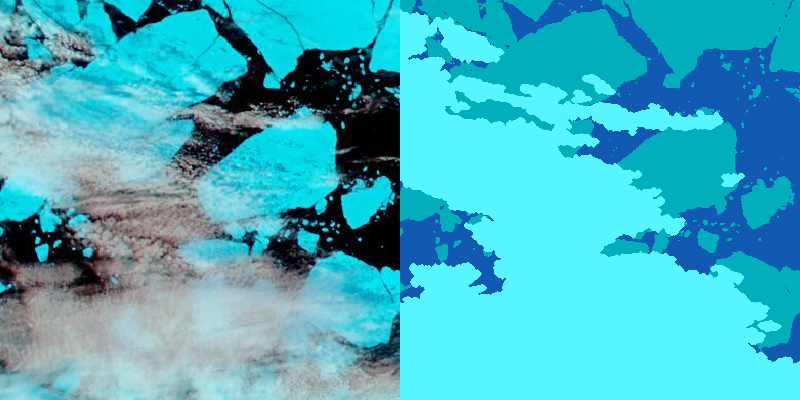

In [22]:
mosaicview(fc_img, view_seg_random(segments), nrow=1)

In [24]:
#### Use the previously defined test/train split ####
using CSV
prior_data = DataFrame(CSV.File("../data/train_test_split.csv")) # want to use CSVFiles but need a few extra steps
dataset.info[:, :training_sample] = prior_data[:, :training_sample]
dataset.info[:, :testing_sample] = prior_data[:, :testing_sample]
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

# Add column with cloud fraction path
cloudfrac_loc = "../data/cloudfraction_numeric/"
transform!(train_cases.info, [:case_number, :region, :satellite, :start_date] => ByRow((cn, r, s, d) ->
    join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "cloudfraction.csv"], "-")) => :cloudfrac_file)

train_tc_imgs = modis_truecolor.(train_cases)
train_fc_imgs = modis_falsecolor.(train_cases)
train_binary_floes = validated_binary_floes.(train_cases)
train_land_masks = modis_landmask.(train_cases) .|> r -> r .> 0; # Load land masks and convert to binary
train_landfast_ice_masks = validated_binary_landfast.(train_cases);

# Add column with cloud fraction path
cloudfrac_loc = "../data/cloudfraction_numeric/"
transform!(train_cases.info, [:case_number, :region, :satellite, :start_date] => ByRow((cn, r, s, d) ->
    join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "cloudfraction.csv"], "-")) => :cloudfrac_file)

# Load numeric cloud fraction data
train_modis_cloudfrac = load.(joinpath.(cloudfrac_loc, train_cases.info[:, :cloudfrac_file])) .|> 
                            DataFrame .|> r -> Array(r[:, 2:end]);

function masked_mean(data, mask)
    d = vec(data)
    m = vec(mask) .> 0
    return mean(d[.!m])
end

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

fill_missing!(train_binary_floes)
fill_missing!(train_landfast_ice_masks)


# Generate binary MODIS mask with 75% threshold
modis_cloud_masks = [m .> 75 for (m, f) in zip(train_modis_cloudfrac, train_fc_imgs)]

# compute MODIS estimated cloud fraction for all pixels
train_cases.info[:, :lookup_index] .= 1:length(train_cases) # This gives us the index for the data loaders
train_cases.info[:, "cloud_fraction_modis"] = round.(mean.(train_modis_cloudfrac) ./ 100, digits=2);
train_cases.info[:, "cloud_fraction_modis_ocean"] = round.(masked_mean.(train_modis_cloudfrac, train_land_masks)./ 100, digits=2);

In [85]:
# Still some challenges loading the training ice/water/cloud masks

# train_ice_masks = validated_binary_ice.(train_cases);
# train_cloud_masks = validated_binary_cloud.(train_cases);
# train_water_masks = validated_binary_water.(train_cases);
# fill_missing!(train_ice_masks)
# fill_missing!(train_water_masks)


In [32]:
# variant of this should work, just need an if-then for filling in blank if the file doesn't exist yet
data_loc = "../../ice_floe_validation_dataset/data/validation_dataset/"
file_names = [
     join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "binary_water_samples.png"], "-")
    for (cn, r, s, d) in zip(
            train_cases.info.case_number,
            train_cases.info.region,
            train_cases.info.satellite,
            train_cases.info.start_date
            )
    ]
train_buffers = create_coastal_buffer_mask.(train_land_masks, [strel_disk(25)]);
train_binary_water_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_water_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(file_names, train_cases.info.water_sample)
        ];
train_binary_cloud_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_cloud_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water"=>"cloud"), train_cases.info.cloud_sample)
        ];
train_binary_ice_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_ice_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water"=>"ice"), train_cases.info.ice_sample)
        ];

In [33]:
# corrections
manual_low = train_cases.info.cloud_fraction_manual .<= 0.1
modis_high = train_cases.info.cloud_fraction_modis .> 0.3
train_cases.info[manual_low .&& modis_high,  [:cloud_fraction_manual, :cloud_fraction_modis, :lookup_index, :case_number]]

Row,cloud_fraction_manual,cloud_fraction_modis,lookup_index,case_number
,Float64,Float64,Int64,Int64
1,0.0,0.5,11,11
2,0.1,0.88,107,181


In [34]:
# computing the error in the classification function
# background / no label = 0 (not evaluating land classification!)
# true water = 1 -> water samples masks
# true ice = 2 -> ice samples masks + ice floes for cases with modis cloud < 25%
# true cloud = 3 -> modis cloud mask > 75 & not land or cloud sample

# To compute the loss, we want to find the fraction of non-background for each category which 
# the segmented and true images don't match. We need to do this per category

labeled_ground_truth = [zeros(Int64, size(train_land_masks[1])) for i in 1:length(train_land_masks)];
for idx in 1:length(labeled_ground_truth)
    cb = train_binary_cloud_samples[idx]
    ib = train_binary_ice_samples[idx]
    cm = apply_landmask(train_modis_cloudfrac[idx], train_buffers[idx])
    fl = train_binary_floes[idx]
    w = train_binary_water_samples[idx]
    labeled_ground_truth[idx][w .> 0] .= 1
    # Non-cloudy ice floes
    labeled_ground_truth[idx][(fl .> 0) .&& (cm .< 25)] .= 2
    labeled_ground_truth[idx][ib .> 0] .= 2
    if idx ∉ [11, 107] # check lookup numbers in cell above
        labeled_ground_truth[idx][cm .> 95] .= 3 # Note -- some errors in MODIS mask! e.g. case 11.
    end
    labeled_ground_truth[idx][cb .> 0] .= 3
end



In [162]:
segments = ift_classification.(train_fc_imgs, train_land_masks; tau_7=0.2, tau_1=0.1, tau_2=0.2);

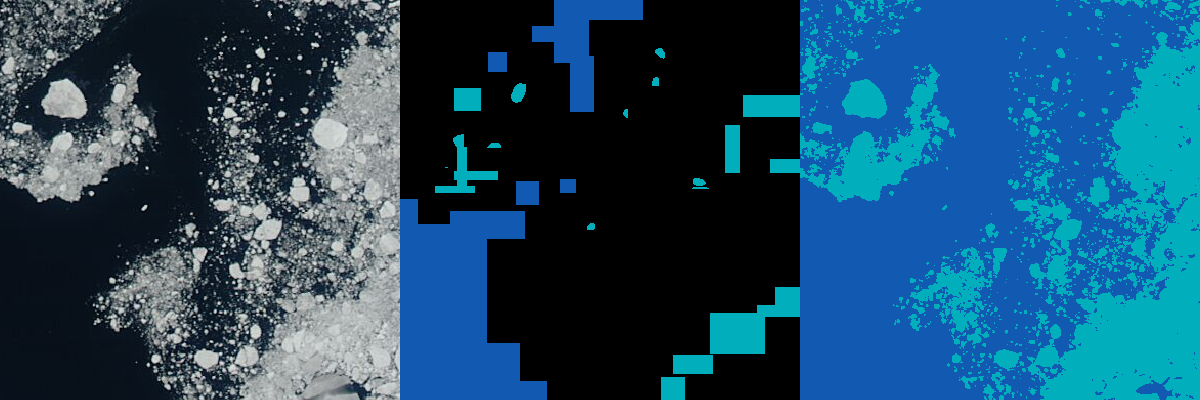

In [163]:
# Case 11: Where we know the MODIS mask is off
idx = 11
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)

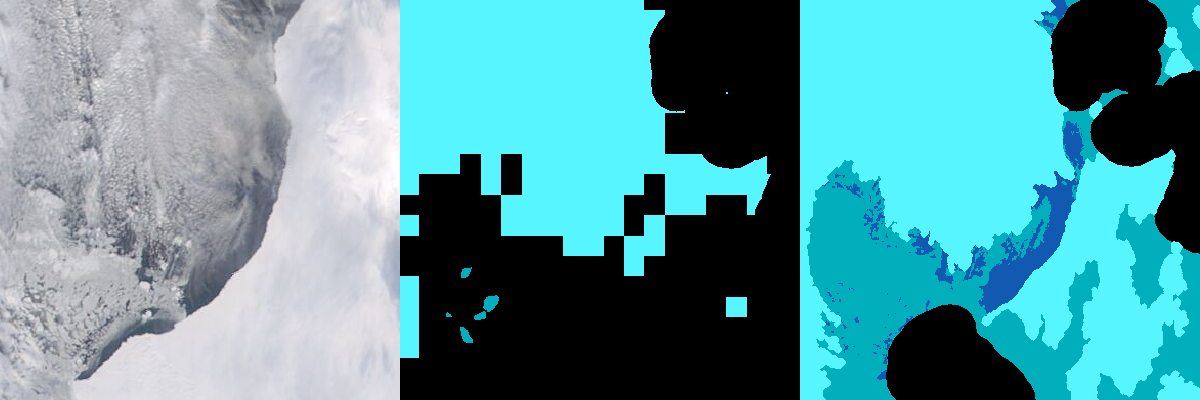

In [166]:
idx = 90
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


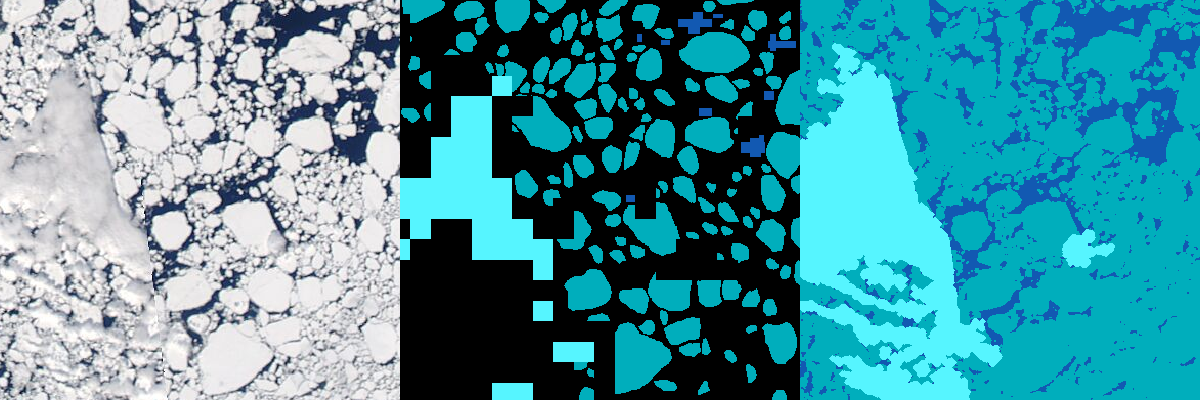

In [167]:
idx = 6
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)

Next step: generate confusion matrix, by class. Check built-in methods for Flux.jl.

- One Hot Arrays -- that's where we transform categorical data into multiple binary columns
- 

In [168]:
labeled_predicted = labels_map.(segments);

In [75]:
"""

Generate a confusion matrix with rows being true values and cols being predicted.
Only computes values where the ground truth GT is not equal to 0.
"""
function confusion_matrix(GT, P; classes=1:3, normalize=false)
    n = length(classes)
    if normalize
        CM = zeros(Float64, (n, n))    
    else
        CM = zeros(Int64, (n, n))
    end
    for (row, ci) in enumerate(classes)
        for (col, cj) in enumerate(classes)
            CM[row, col] = sum((GT .== ci .&& GT .!= 0) .&& (P .== cj .&&  GT .!= 0))
            if normalize
                n = sum(GT .== ci .&& GT .!= 0)
                if n > 0
                    CM[row, col] /= n
                end
            end
        end
    end
    return CM
end

confusion_matrix

In [77]:
# label_map=Dict("land"=>0, "water"=>1, "ice"=>2, "cloud"=>3)
idx = 14
cm = confusion_matrix(labeled_ground_truth[idx], labeled_predicted[idx]; normalize=false)
function prettyprint_cm(cm)
    println("predicted: water      ice    cloud")
    for (ii, label) in enumerate(["water", "ice", "cloud"])
        println(rpad(label, 8, " "), join([lpad(x, 8, " ") for x in cm[ii, :]], " "))
    end
end
prettyprint_cm(cm)

predicted: water      ice    cloud
water        410        0        8
ice            0      347      915
cloud       4407     1251    11363


Interpretting the confusion matrix. Summing across the rows gives the total of true values in each category, while summing down the columns gives the number of predictions in each. Anything off-diagonal is a miss-prediction.

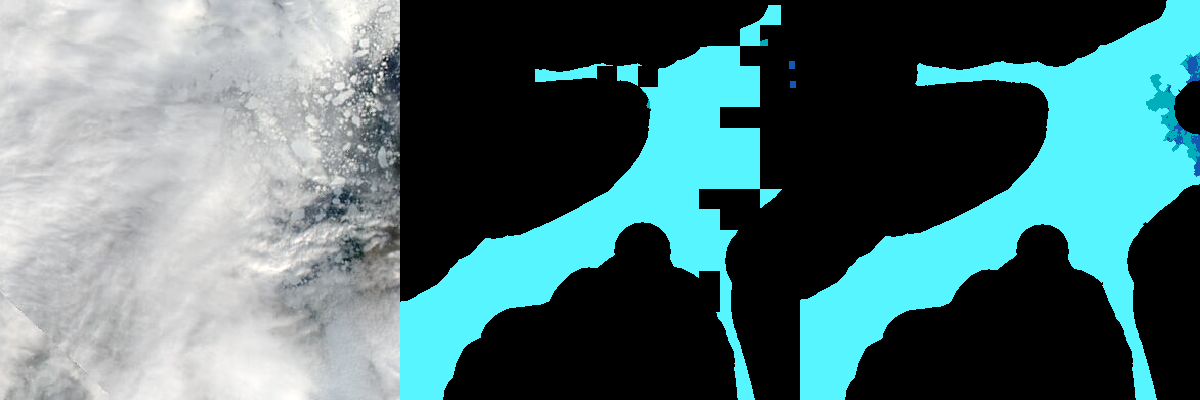

In [78]:
idx = 13
mosaicview(train_tc_imgs[idx],
        view_seg_random(SegmentedImage(train_fc_imgs[idx], labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


In [80]:
cms = confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false);


In [81]:
overall = sum(cms)
prettyprint_cm(overall)

predicted: water      ice    cloud
water     217275       37     1074
ice         1015   234954   233148
cloud     273089   175421 10769650


In [63]:
# "land"=>0, "water"=>1, "ice"=>2, "cloud"=>3

# Construct histograms of band-wise colors
modis_threshold = 75
b2_clouds = []
b7_clouds = []
b1_clouds = []
b2_ice = []
b1_ice = []
b7_ice = []
for idx in train_cases.info.lookup_index
    clouds = vec(labeled_ground_truth[idx] .== 3) 
    water = vec(labeled_ground_truth[idx] .== 1)
    ice = vec(labeled_ground_truth[idx] .== 2)
    b2 = green.(train_fc_imgs[idx])
    b7 = red.(train_fc_imgs[idx])
    b1 = vec(blue.(train_fc_imgs[idx]))

    push!(b2_clouds, Float64.(b2[clouds]))
    push!(b7_clouds, Float64.(b7[clouds]))
    push!(b1_clouds, Float64.(b1[clouds]))

    push!(b2_ice, Float64.(b2[ice]))
    push!(b7_ice, Float64.(b7[ice]))
    push!(b1_ice, Float64.(b1[ice]))
    
end
b1_clouds = vcat(b1_clouds...)
b2_clouds = vcat(b2_clouds...)
b7_clouds = vcat(b7_clouds...)
b2_ice = vcat(b2_ice...)
b7_ice = vcat(b7_ice...)
b1_ice = vcat(b1_ice...);

## Normalized confusion matrix

In [82]:
# true number per category = sum down columns
overall ./ sum(overall; dims=2)

3×3 Matrix{Float64}:
 0.994913    0.000169425  0.0049179
 0.00216364  0.500843     0.496993
 0.0243435   0.0156372    0.960019

In [83]:
using LinearAlgebra
tr(overall) ./ sum(sum(overall))

0.9425664912571438

In [84]:
collect(0.025:0.025:0.5)

20-element Vector{Float64}:
 0.025
 0.05
 0.075
 0.1
 0.125
 0.15
 0.175
 0.2
 0.225
 0.25
 0.275
 0.3
 0.325
 0.35
 0.375
 0.4
 0.425
 0.45
 0.475
 0.5

## Calibration

Running the classification and accuracy test for one parameter takes 14 seconds, so doing a simple parameter sweep won't take very long.

In [115]:
##### 
results = DataFrame(
            tau_1=Float64[],
            tau_2=Float64[],
            tau_7=Float64[],
            water=Float64[],
            ice=Float64[],
            cloud=Float64[],
            overall=Float64[]
    )
# Save results as 
@time begin
    for tau_2 in 0.05:0.05:1
        for tau_1 in 0.05:0.05:1
            if (tau_2 * 100) % 20 == 0
                println(tau_2, " ", tau_1)
            end
            
            for tau_7 in 0.05:0.05:1
                parameters = (
                    tau_1=tau_1,
                    tau_2=tau_2,
                    tau_7=tau_7,
                )
                segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
                labeled_predicted = labels_map.(segments);
                conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
                overall_accuracy = tr(conf) / sum(sum(conf))
                category_accuracy = diag(conf ./ sum(conf; dims=2))
                push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
            end
        end
    end
end

0.2 0.05
0.2 0.1
0.2 0.15
0.2 0.2
0.2 0.25
0.2 0.3
0.2 0.35
0.2 0.4
0.2 0.45
0.2 0.5
0.2 0.55
0.2 0.6
0.2 0.65
0.2 0.7
0.2 0.75
0.2 0.8
0.2 0.85
0.2 0.9
0.2 0.95
0.2 1.0


LoadError: InterruptException:

In [ ]:
@time begin
    for tau_2 in 0.3:0.05:1
        for tau_1 in 0.05:0.05:1
            if (tau_2 * 100) % 20 == 0
                println(tau_2, " ", tau_1)
            end
            
            for tau_7 in 0.05:0.05:1
                parameters = (
                    tau_1=tau_1,
                    tau_2=tau_2,
                    tau_7=tau_7,
                )
                segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
                labeled_predicted = labels_map.(segments);
                conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
                overall_accuracy = tr(conf) / sum(sum(conf))
                category_accuracy = diag(conf ./ sum(conf; dims=2))
                push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
            end
        end
    end
end

In [125]:
maximum.(eachcol(results))

7-element Vector{Float64}:
 1.0
 0.3
 1.0
 1.0
 0.9977981181591243
 0.9569938385617606
 0.9447552495716736

In [138]:
save("../data/classification_accuracy.csv", results)

In [133]:
segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
                labeled_predicted = labels_map.(segments);
                conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
                overall_accuracy = tr(conf) / sum(sum(conf))
                category_accuracy = diag(conf ./ sum(conf; dims=2))

6-element Vector{Float64}:
 0.05
 0.1
 0.15
 0.2
 0.25
 0.3

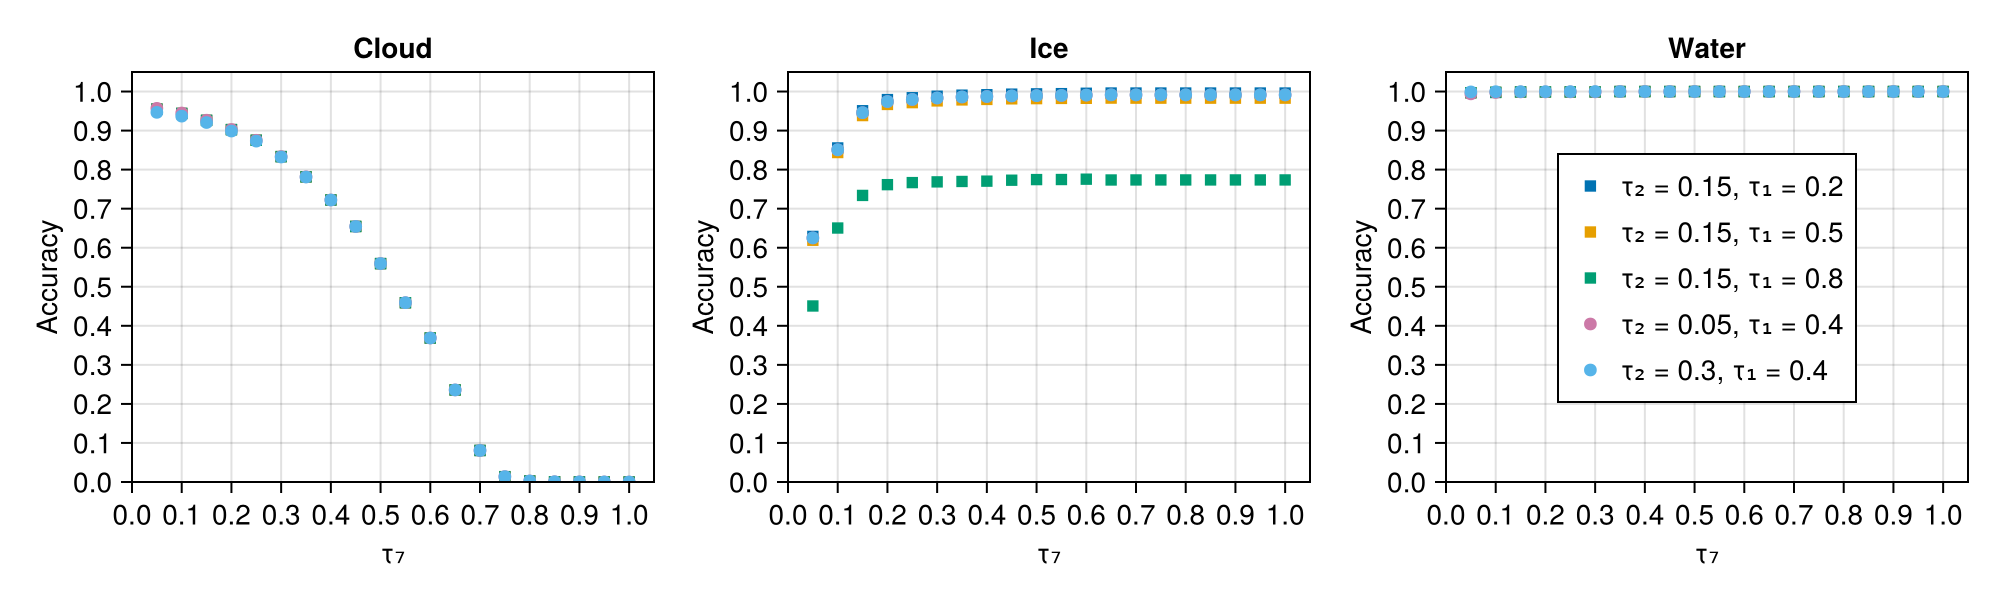

In [136]:
f = CairoMakie.Figure(size=(1000, 300))
ax1 = CairoMakie.Axis(f[1, 1], limits=(0, 1.05, 0, 1.05), title="Cloud", yticks=0:0.1:1, xticks=0:0.1:1, xlabel="τ₇", ylabel="Accuracy")
ax2 = CairoMakie.Axis(f[1, 2], limits=(0, 1.05, 0, 1.05), xticks=0:0.1:1, title="Ice", yticks=0:0.1:1, xlabel="τ₇", ylabel="Accuracy")
ax3 = CairoMakie.Axis(f[1, 3], limits=(0, 1.05, 0, 1.05), xticks=0:0.1:1, title="Water", yticks=0:0.1:1, xlabel="τ₇", ylabel="Accuracy")

for (idx, label, marker) in zip(
        [results.tau_2 .== 0.15 .&& results.tau_1 .== 0.2,
         results.tau_2 .== 0.15 .&& results.tau_1 .== 0.5,
         results.tau_2 .== 0.15 .&& results.tau_1 .== 0.8,
         results.tau_2 .== 0.05 .&& results.tau_1 .== 0.4,
         results.tau_2 .== 0.3 .&& results.tau_1 .== 0.4],
        ["τ₂ = 0.15, τ₁ = 0.2", "τ₂ = 0.15, τ₁ = 0.5", "τ₂ = 0.15, τ₁ = 0.8", "τ₂ = 0.05, τ₁ = 0.4", "τ₂ = 0.3, τ₁ = 0.4"],
        [:rect, :rect, :rect, :circle, :circle])

    scatter!(ax1, results.tau_7[idx], results.cloud[idx], label=label, marker=marker)
    scatter!(ax2, results.tau_7[idx], results.ice[idx], label=label, marker=marker)
    scatter!(ax3, results.tau_7[idx], results.water[idx], label=label, marker=marker)
end
Legend(f[1, 3], ax3, tellheight=false, tellwidth=false)
f

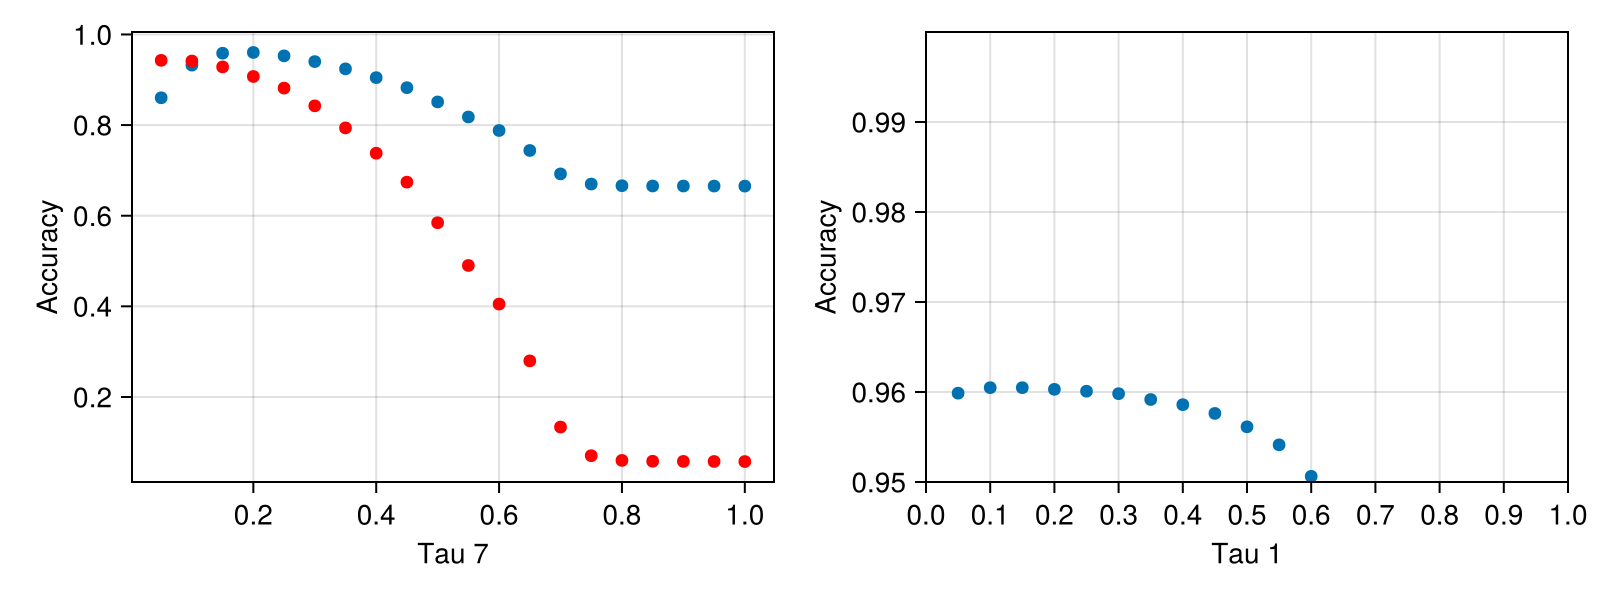

In [161]:
f = CairoMakie.Figure(size=(800, 300))
ax = CairoMakie.Axis(f[1,1], ylabel="Accuracy", xlabel="Tau 7")
subset_df = results[results.tau_1 .== 0.2 .&& results.tau_2 .== 0.15, :]
scatter!(ax, subset_df.tau_7, (subset_df[:, :ice] .+ subset_df[:, :cloud] .+ subset_df[:, :water]) ./ 3)
scatter!(ax, subset_df.tau_7, subset_df[:, :overall], color=:red)


ax = CairoMakie.Axis(f[1,2], ylabel="Accuracy", xlabel="Tau 1", limits=(0, 1, 0.95, 1),  xticks=0:0.1:1)
subset_df = results[results.tau_7 .== 0.2 .&& results.tau_2 .== 0.15, :]
scatter!(ax, subset_df.tau_1,  (subset_df[:, :ice] .+ subset_df[:, :cloud] .+ subset_df[:, :water]) ./ 3)
scatter!(ax, subset_df.tau_1, subset_df[:, :overall], color=:red)

current_figure()

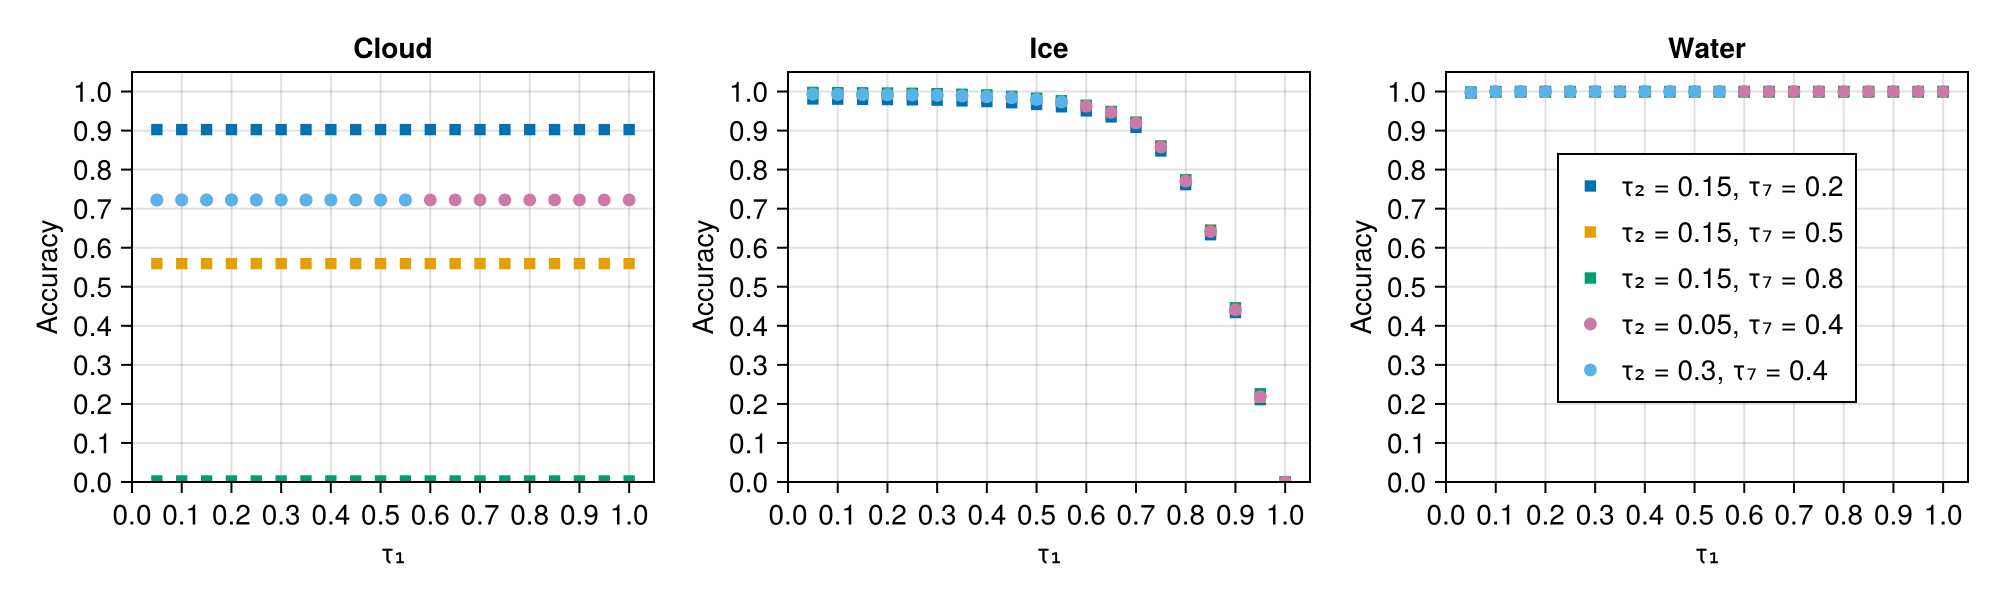

In [137]:
f = CairoMakie.Figure(size=(1000, 300))
ax1 = CairoMakie.Axis(f[1, 1], limits=(0, 1.05, 0, 1.05), title="Cloud", yticks=0:0.1:1, xticks=0:0.1:1, xlabel="τ₁", ylabel="Accuracy")
ax2 = CairoMakie.Axis(f[1, 2], limits=(0, 1.05, 0, 1.05), xticks=0:0.1:1, title="Ice", yticks=0:0.1:1, xlabel="τ₁", ylabel="Accuracy")
ax3 = CairoMakie.Axis(f[1, 3], limits=(0, 1.05, 0, 1.05), xticks=0:0.1:1, title="Water", yticks=0:0.1:1, xlabel="τ₁", ylabel="Accuracy")

for (idx, label, marker) in zip(
        [results.tau_2 .== 0.15 .&& results.tau_7 .== 0.2,
         results.tau_2 .== 0.15 .&& results.tau_7 .== 0.5,
         results.tau_2 .== 0.15 .&& results.tau_7 .== 0.8,
         results.tau_2 .== 0.05 .&& results.tau_7 .== 0.4,
         results.tau_2 .== 0.3 .&& results.tau_7 .== 0.4],
        ["τ₂ = 0.15, τ₇ = 0.2", "τ₂ = 0.15, τ₇ = 0.5", "τ₂ = 0.15, τ₇ = 0.8", "τ₂ = 0.05, τ₇ = 0.4", "τ₂ = 0.3, τ₇ = 0.4"],
        [:rect, :rect, :rect, :circle, :circle])

    scatter!(ax1, results.tau_1[idx], results.cloud[idx], label=label, marker=marker)
    scatter!(ax2, results.tau_1[idx], results.ice[idx], label=label, marker=marker)
    scatter!(ax3, results.tau_1[idx], results.water[idx], label=label, marker=marker)
end
Legend(f[1, 3], ax3, tellheight=false, tellwidth=false)
f

The algorithm shows essentially no sensitivity to the choice of tau_2 and tau_1 for the two values shown, while for tau_7, we have strong sensitivity with increasing accuracy for ice as tau 7 goes up, and decreasing accuracy for cloud. 

I can get this figure down to a single panel.


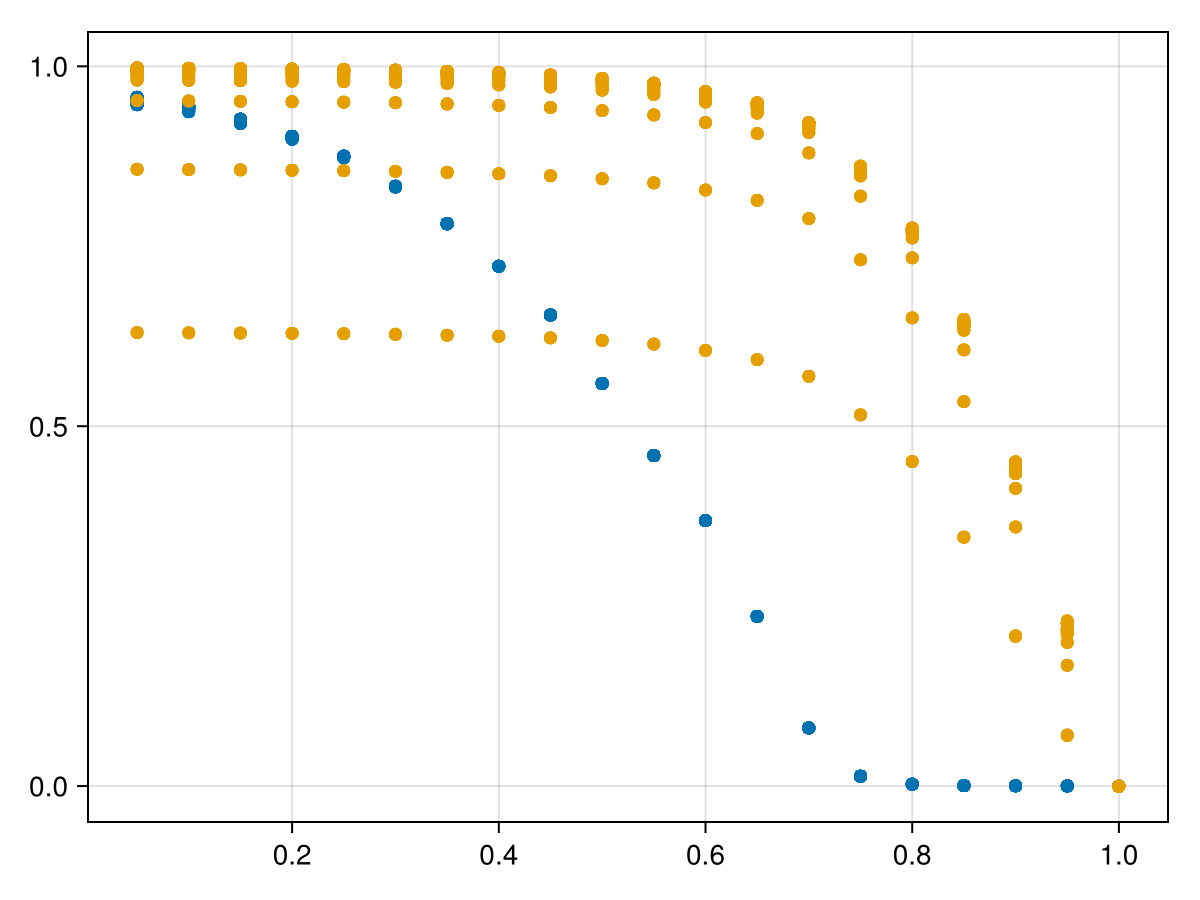

In [170]:
f = CairoMakie.Figure()
ax = CairoMakie.Axis(f[1,1])
scatter(results.tau_7, results.cloud)
scatter!(results.tau_1, results.ice)
current_figure()

In [297]:
# Append to results
@time begin
    tau_1 = 0.2
    tau_2 = 0.2
    for tau_7 in 0.1:0.05:0.6
        parameters = (
            tau_1=tau_1,
            tau_2=tau_2,
            tau_7=tau_7,
        )
        segments = ift_classification.(train_fc_imgs, train_land_masks; parameters...);
        labeled_predicted = labels_map.(segments);
        conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
        overall_accuracy = tr(conf) / sum(sum(conf))
        category_accuracy = diag(conf ./ sum(conf; dims=2))
        push!(results, [tau_1, tau_2, tau_7, category_accuracy..., overall_accuracy])
    end
end

5-element Vector{Float64}:
 0.2
 0.25
 0.3
 0.35
 0.4

In [171]:
segments = ift_classification.(train_fc_imgs, train_land_masks; tau_7=0.2, tau_1=0.1, tau_2=0.2);
labeled_predicted = labels_map.(segments);
conf = sum(confusion_matrix.(labeled_ground_truth, labeled_predicted; normalize=false));
overall_accuracy = tr(conf) / sum(sum(conf))
category_accuracy = diag(conf ./ sum(conf; dims=2));

In [177]:
prettyprint_cm(round.(conf ./ sum(conf; dims=2), digits=2))

predicted: water      ice    cloud
water        1.0      0.0      0.0
ice          0.0     0.98     0.02
cloud       0.03     0.07      0.9


In [178]:
sum(conf; dims=2)

3×1 Matrix{Int64}:
   218386
   468923
 11218132

In [179]:
sum(conf; dims=1)

1×3 Matrix{Int64}:
 572387  1208235  10124819

## Load test data - run the training data loader first

In [197]:
transform!(test_cases.info, [:case_number, :region, :satellite, :start_date] => ByRow((cn, r, s, d) ->
    join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "cloudfraction.csv"], "-")) => :cloudfrac_file)

test_tc_imgs = modis_truecolor.(test_cases)
test_fc_imgs = modis_falsecolor.(test_cases)
# test_binary_floes = validated_binary_floes.(test_cases)
test_land_masks = modis_landmask.(test_cases) .|> r -> r .> 0; # Load land masks and convert to binary
# test_landfast_ice_masks = validated_binary_landfast.(test_cases);

# Add column with cloud fraction path
cloudfrac_loc = "../data/cloudfraction_numeric/"
transform!(test_cases.info, [:case_number, :region, :satellite, :start_date] => ByRow((cn, r, s, d) ->
    join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "cloudfraction.csv"], "-")) => :cloudfrac_file)

# Load numeric cloud fraction data
test_modis_cloudfrac = load.(joinpath.(cloudfrac_loc, test_cases.info[:, :cloudfrac_file])) .|> 
                            DataFrame .|> r -> Array(r[:, 2:end]);

In [198]:
# Generate binary MODIS mask with 75% threshold
modis_cloud_masks = [m .> 75 for (m, f) in zip(test_modis_cloudfrac, test_fc_imgs)]

# compute MODIS estimated cloud fraction for all pixels
test_cases.info[:, :lookup_index] .= 1:length(test_cases) # This gives us the index for the data loaders
test_cases.info[:, "cloud_fraction_modis"] = round.(mean.(test_modis_cloudfrac) ./ 100, digits=2);
test_cases.info[:, "cloud_fraction_modis_ocean"] = round.(masked_mean.(test_modis_cloudfrac, test_land_masks)./ 100, digits=2);

In [202]:
# variant of this should work, just need an if-then for filling in blank if the file doesn't exist yet
data_loc = "../../ice_floe_validation_dataset/data/validation_dataset/"

file_names = [
     join([lpad(cn, 3, "0"), r, Dates.format(d, "yyyymmdd"), s, "binary_water_samples.png"], "-")
    for (cn, r, s, d) in zip(
            test_cases.info.case_number,
            test_cases.info.region,
            test_cases.info.satellite,
            test_cases.info.start_date
            )
    ]
test_buffers = create_coastal_buffer_mask.(test_land_masks, [strel_disk(25)]);
test_binary_floes = [sample_present==1 ? load.(joinpath.(data_loc, "binary_floes", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water_samples"=>"floes"), test_cases.info.floe_sample)
        ];
test_binary_water_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_water_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(file_names, test_cases.info.water_sample)
        ];
test_binary_cloud_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_cloud_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water"=>"cloud"), test_cases.info.cloud_sample)
        ];
test_binary_ice_samples = [sample_present==1 ? load.(joinpath.(data_loc, "binary_ice_samples", f)) .|> r -> Gray.(r) .> 0 : zeros((400,400))
    for (f, sample_present) in zip(replace.(file_names, "water"=>"ice"), test_cases.info.ice_sample)
        ];

In [203]:
test_labeled_ground_truth = [zeros(Int64, size(test_land_masks[1])) for i in 1:length(test_land_masks)];
for idx in 1:length(test_labeled_ground_truth)
    cb = test_binary_cloud_samples[idx]
    ib = test_binary_ice_samples[idx]
    cm = apply_landmask(test_modis_cloudfrac[idx], test_buffers[idx])
    fl = test_binary_floes[idx]
    w = test_binary_water_samples[idx]
    test_labeled_ground_truth[idx][w .> 0] .= 1
    # Non-cloudy ice floes
    test_labeled_ground_truth[idx][(fl .> 0) .&& (cm .< 25)] .= 2
    test_labeled_ground_truth[idx][ib .> 0] .= 2
    if idx ∉ [11, 107] # check lookup numbers in cell above
        test_labeled_ground_truth[idx][cm .> 95] .= 3 # Note -- some errors in MODIS mask! e.g. case 11.
    end
    test_labeled_ground_truth[idx][cb .> 0] .= 3
end


# Confusion matrix

In [ ]:
segments = ift_classification.(test_fc_imgs, test_land_masks; tau_7=0.2, tau_1=0.1, tau_2=0.2);
labeled_predicted = labels_map.(segments);
conf = sum(confusion_matrix.(test_labeled_ground_truth, labeled_predicted; normalize=false));
overall_accuracy = tr(conf) / sum(sum(conf))
category_accuracy = diag(conf ./ sum(conf; dims=2));

In [219]:
prettyprint_cm(conf)
println()
prettyprint_cm(round.(conf ./ sum(conf; dims=2), digits=2))

predicted: water      ice    cloud
water     145854     1056        8
ice          674   357132     6270
cloud     211586   324043  7467284

predicted: water      ice    cloud
water       0.99     0.01      0.0
ice          0.0     0.98     0.02
cloud       0.03     0.04     0.93


In [231]:
prettyprint_cm(round.(conf ./ sum(conf; dims=1), digits=2))

predicted: water      ice    cloud
water       0.41      0.0      0.0
ice          0.0     0.52      0.0
cloud       0.59     0.47      1.0


In [229]:
conf ./ sum(conf; dims=1)

3×3 Matrix{Float64}:
 0.407284    0.00154786  1.07044e-6
 0.00188208  0.523477    0.000838957
 0.590834    0.474975    0.99916

In [209]:
print("Overall accuracy: ", round(overall_accuracy, digits=3))

Overall accuracy: 0.936

In [225]:
sum(sum(conf; dims=2)) / 1e5

85.13907

Compute: precision and recall per item (note connection with Producer's and User's accuracy)

Producers accuracy = number correct / number reference (recall)  
Users accuracy = number correct / number predicted (precision)

Add these as columns, and then add total number of cases

In [220]:
# Dividing the diagonal (true positives) by the number of true members of each category
# This is the "Producer's accuracy", or the Recall
diag(conf) ./ sum(conf; dims=2)

3×1 Matrix{Float64}:
 0.9927578649314583
 0.9809270591854448
 0.933070745614753

In [235]:
# Dividing the diagonal (true positives) by the number of predicted members of each category
# This is the "Users's accuracy", or the Precision
sum(conf; dims=2) / 1e5

3×1 Matrix{Float64}:
  1.46918
  3.64076
 80.02913

## Example image choices -- cases where there is a substantial amount of cloud misclassified as water

water = 1

ice = 2

cloud = 3

In [250]:

misclassified_cloud_water = [sum((test_labeled_ground_truth[idx] .== 3) .&& (labeled_predicted[idx] .== 1)) for idx in test_cases.info.lookup_index];
misclassified_cloud_ice = [sum((test_labeled_ground_truth[idx] .== 3) .&& (labeled_predicted[idx] .== 2)) for idx in test_cases.info.lookup_index];

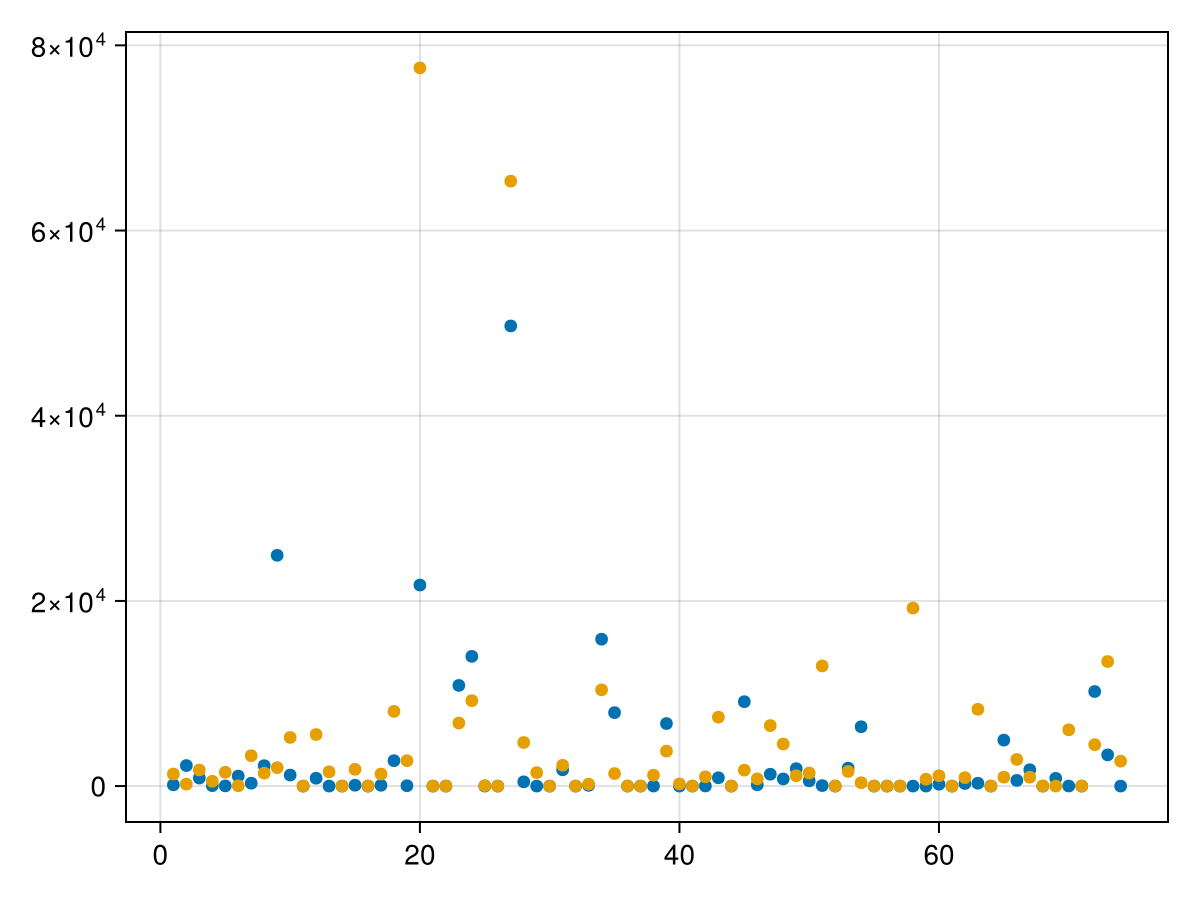

In [251]:
scatter(misclassified_cloud_water)
scatter!(misclassified_cloud_ice)
current_figure()

In [263]:
test_cases.info[misclassified_cloud_water .> 1e4, [:case_number, :region, :lookup_index]]

Row,case_number,region,lookup_index
,Int64,String,Int64
1,27,barents_kara_seas,9
2,64,bering_chukchi_seas,20
3,67,bering_chukchi_seas,23
4,68,bering_chukchi_seas,24
5,77,bering_chukchi_seas,27
6,88,east_siberian_sea,34
7,164,laptev_sea,72


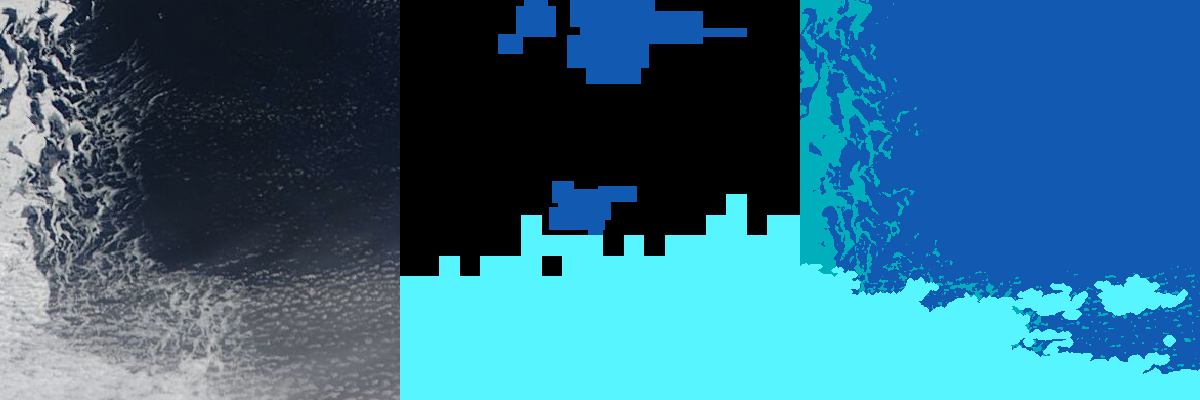

In [264]:
idx = 9
mosaicview(test_tc_imgs[idx],
        view_seg_random(SegmentedImage(test_fc_imgs[idx], test_labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


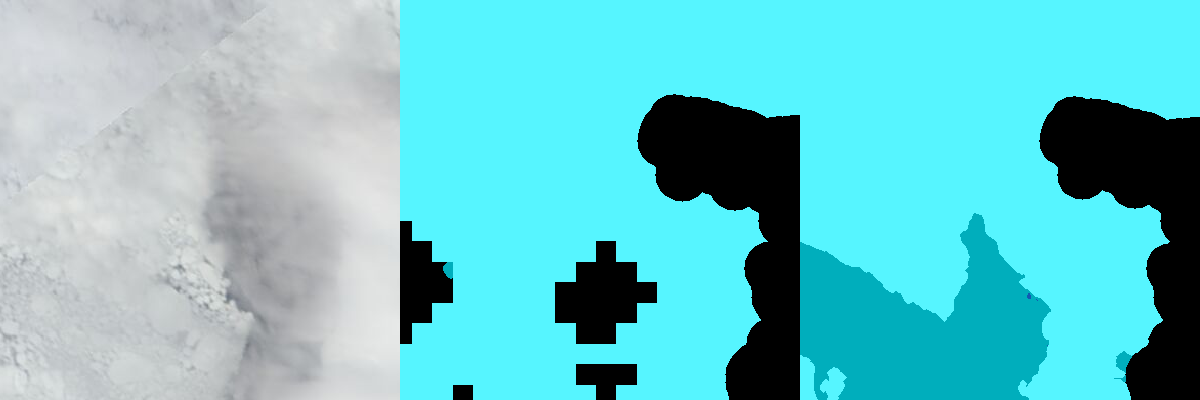

In [258]:
idx = 58
mosaicview(test_tc_imgs[idx],
        view_seg_random(SegmentedImage(test_fc_imgs[idx], test_labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


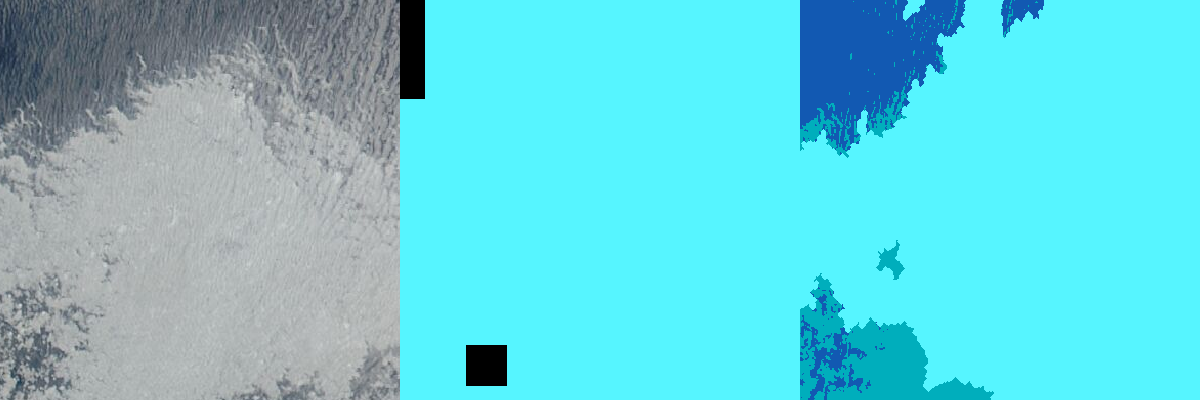

In [262]:
idx = 34
mosaicview(test_tc_imgs[idx],
        view_seg_random(SegmentedImage(test_fc_imgs[idx], test_labeled_ground_truth[idx])),
        view_seg_random(segments[idx]), nrow=1)


### Percentiles

In [67]:
# Clouds
q =[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
DataFrame(percentile = q,
    cloud_band_7 = round.(
        quantile(b7_clouds, q), digits=2),
    cloud_band_2 = round.(
        quantile(b2_clouds, q), digits=2),
    ice_band_7 = round.(
        quantile(b7_ice, q), digits=2),
    ice_band_2 = round.(
        quantile(b2_ice, q), digits=2),
    ice_band_1 = round.(
        quantile(b1_ice, q), digits=2)
)

Row,percentile,cloud_band_7,cloud_band_2,ice_band_7,ice_band_2,ice_band_1
,Float64,Float64,Float64,Float64,Float64,Float64
1,0.01,0.0,0.0,0.0,0.49,0.58
2,0.05,0.04,0.28,0.0,0.63,0.7
3,0.25,0.33,0.67,0.01,0.75,0.82
4,0.5,0.51,0.8,0.03,0.84,0.89
5,0.75,0.64,0.87,0.08,0.93,0.93
6,0.95,0.71,0.95,0.16,0.95,0.96
7,0.99,0.76,1.0,0.31,0.97,0.98


For all three thresholds we are looking for the minimum value, without covering things up that we don't want to cover.
For band 7, 95% of ice is darker than 0.16, and brighter than 0.63 in band 2 while 95% of clouds are brighter than 0.04 in band 7 and brighter than 0.28 in band 2.

For sea ice, 99% of the data has band 7 less than 0.3, and 95% has less than 0.16. We'll start at 0.16, and check performance around there. 

B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]
B7 quantiles[0.03529411764705882, 0.3254901960784314, 0.5058823529411764, 0.6392156862745098, 0.7098039215686275]


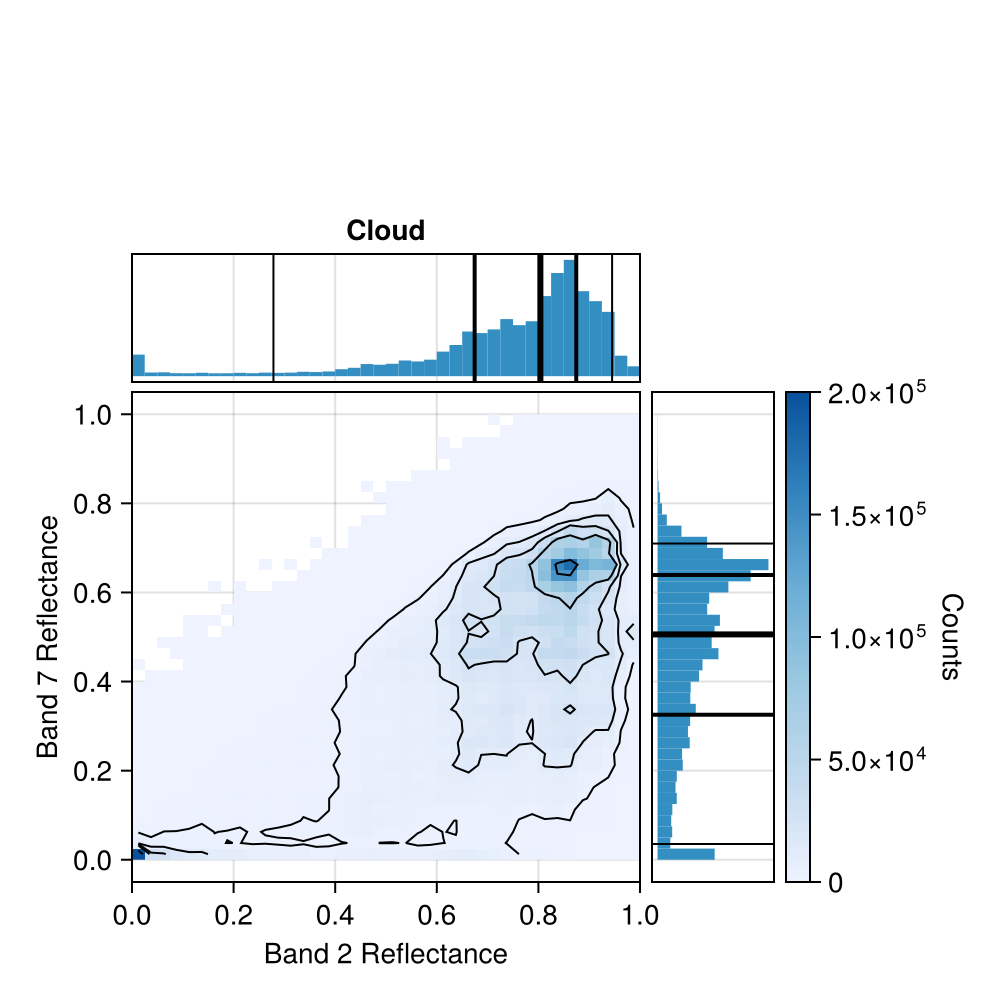

In [340]:
using FHist
using Interpolations

fig = Figure(size=(500,500))

bins = 0:0.025:1
h2 = Hist1D(b2_clouds; binedges=bins);
h7 = Hist1D(b7_clouds, binedges=bins);
h2h7 = Hist2D((b2_clouds, b7_clouds), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax1, _ = hist(fig[1, 1],h2; axis=(xticks=0:0.2:1, yticks=[], title="Cloud"))
ax3, _h2h7 = plot(fig[2, 1], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax3, h2h7; 
    levels=levels, labels=false, color=:black)
Colorbar(fig[2, 3], _h2h7; label="Counts", labelrotation=-pi/2)
ax2, _ = hist(fig[2, 2], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))
ax2.aspect = 0.25
ax1.aspect = 4
b2_qs = quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B2 quantiles", b2_qs)
vlines!(ax1, b2_qs, color=:black, linewidth=1)
vlines!(ax1, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax1, b2_qs[[3]], color=:black, linewidth=3)


b7_qs = quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B7 quantiles", b7_qs)
hlines!(ax2, b7_qs, color=:black, linewidth=1)
hlines!(ax2, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax2, b7_qs[[3]], color=:black, linewidth=3)


linkyaxes!(ax3, ax2)
linkxaxes!(ax3, ax1)
hidedecorations!(ax1, grid = false)
hidedecorations!(ax2, grid = false)
colgap!(fig.layout, -90)
rowgap!(fig.layout,  -85)
# statbox!(fig, h2h7; position=(2,4))
# save("../figures/fig_04a_cloud_histogram.pdf", fig)
# save("../figures/fig_04a_cloud_histogram.pdf", fig, px_per_unit=1)
fig

In [387]:
fig = Figure(size=(1000,500))

# Clouds on left
bins = 0:0.025:1
h2 = Hist1D(b2_clouds; binedges=bins);
h7 = Hist1D(b7_clouds, binedges=bins);
h2h7 = Hist2D((b2_clouds, b7_clouds), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax11, _ = hist(fig[1, 1],h2; axis=(xticks=0:0.2:1, yticks=[], title="Cloud"))
ax21, _h2h7 = plot(fig[2, 1], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax21, h2h7; 
    levels=levels, labels=false, color=:black)
ax22, _ = hist(fig[2, 2], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))

b2_qs = quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B2 quantiles", b2_qs)
vlines!(ax11, b2_qs, color=:black, linewidth=1)
vlines!(ax11, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax11, b2_qs[[3]], color=:black, linewidth=3)

b7_qs = quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
hlines!(ax22, b7_qs, color=:black, linewidth=1)
hlines!(ax22, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax22, b7_qs[[3]], color=:black, linewidth=3)

linkyaxes!(ax21, ax22)
linkxaxes!(ax11, ax21)
hidedecorations!(ax11, grid = false)
hidedecorations!(ax22, grid = false)

# RHS
idx = b2_non_clouds .> 0.2
h2 = Hist1D(b2_non_clouds[idx]; binedges=bins);
h7 = Hist1D(b7_non_clouds[idx], binedges=bins);
h2h7 = Hist2D((b2_non_clouds[idx], b7_non_clouds[idx]), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax14, _ = hist(fig[1, 4],h2; axis=(xticks=0:0.2:1, yticks=[], title="Non-Cloud"))
ax25, _ = hist(fig[2, 5], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))
ax24, _h2h7 = plot(fig[2, 4], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax24, h2h7; 
    levels=levels, labels=false, color=:black)

ax22.aspect = 0.25
ax11.aspect = 4
# ax21.aspect=1
# ax24.aspect = 1
ax14.aspect = 4
ax25.aspect = 0.25

b2_qs = quantile(b2_non_clouds[idx], [0.05, 0.25, 0.5, 0.75, 0.95])
vlines!(ax14, b2_qs, color=:black, linewidth=1)
vlines!(ax14, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax14, b2_qs[[3]], color=:black, linewidth=3)

b7_qs = quantile(b7_non_clouds[idx], [0.05, 0.25, 0.5, 0.75, 0.95])
hlines!(ax25, b7_qs, color=:black, linewidth=1)
hlines!(ax25, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax25, b7_qs[[3]], color=:black, linewidth=3)

linkyaxes!(ax24, ax25)
linkxaxes!(ax14, ax24)
hidedecorations!(ax25, grid = false)
hidedecorations!(ax14, grid = false)

colgap!(fig.layout, -90)
rowgap!(fig.layout,  -85)

ax14.protrusion=(0,0,0,0)

current_figure()

B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]


LoadError: FieldError: type Makie.Axis has no field `protrusion`, available fields: `parent`, `layoutobservables`, `blockscene`, `scene`, `xaxislinks`, `yaxislinks`, `targetlimits`, `finallimits`, `block_limit_linking`, `mouseeventhandle`, `scrollevents`, `keysevents`, `interactions`, `xaxis`, `yaxis`, `elements`, `dim1_conversion`, `dim2_conversion`, `xlabel`, `ylabel`, `title`, `titlefont`, `titlesize`, `titlegap`, `titlevisible`, `titlealign`, `titlecolor`, `titlelineheight`, `subtitle`, `subtitlefont`, `subtitlesize`, `subtitlegap`, `subtitlevisible`, `subtitlecolor`, `subtitlelineheight`, `xlabelfont`, `ylabelfont`, `xlabelcolor`, `ylabelcolor`, `xlabelsize`, `ylabelsize`, `xlabelvisible`, `ylabelvisible`, `xlabelpadding`, `ylabelpadding`, `xlabelrotation`, `ylabelrotation`, `xticklabelfont`, `yticklabelfont`, `xticklabelcolor`, `yticklabelcolor`, `xticklabelsize`, `yticklabelsize`, `xticklabelsvisible`, `yticklabelsvisible`, `xticklabelspace`, `yticklabelspace`, `xticklabelpad`, 

In [354]:
h7

edges: [0.0, 0.025, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.225  …  0.775, 0.8, 0.825, 0.85, 0.875, 0.9, 0.925, 0.95, 0.975, 1.0]
bin counts: [505659.0, 113149.0, 129682.0, 121161.0, 131050.0, 170241.0, 159240.0, 170325.0, 223286.0, 217034.0  …  81988.0, 39920.0, 22559.0, 9199.0, 4523.0, 2403.0, 1742.0, 1451.0, 1105.0, 1130.0]
total count: 1.1273077e7

B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]
B7 quantiles[0.03529411764705882, 0.3254901960784314, 0.5058823529411764, 0.6392156862745098, 0.7098039215686275]
B2 quantiles[0.2784313725490196, 0.6745098039215687, 0.803921568627451, 0.8745098039215686, 0.9450980392156862]
B7 quantiles[0.03529411764705882, 0.3254901960784314, 0.5058823529411764, 0.6392156862745098, 0.7098039215686275]


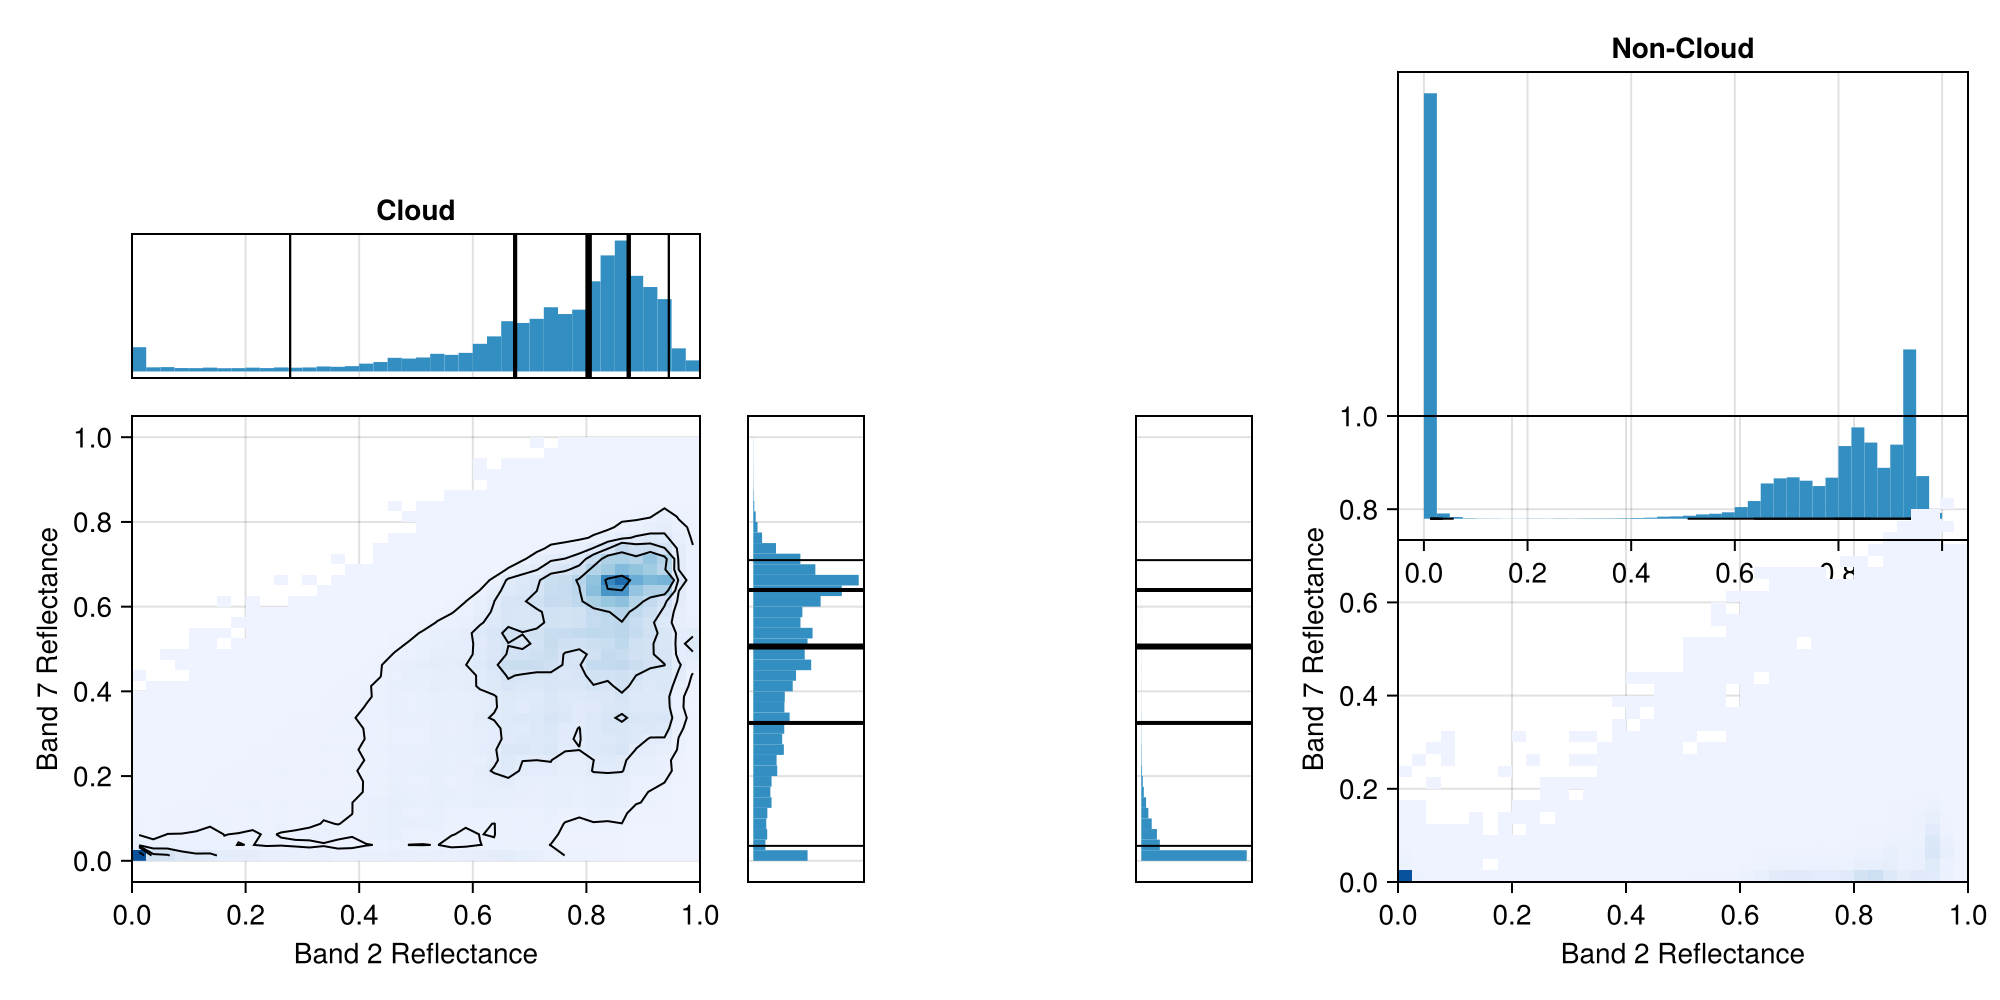

In [342]:
# statbox!(fig, h2h7; position=(2,4))
# save("../figures/fig_04a_cloud_histogram.pdf", fig)
# save("../figures/fig_04a_cloud_histogram.pdf", fig, px_per_unit=1)

# Non-clouds on right
bins = 0:0.025:1
h2 = Hist1D(b2_non_clouds; binedges=bins);
h7 = Hist1D(b7_non_clouds, binedges=bins);
h2h7 = Hist2D((b2_non_clouds, b7_non_clouds), binedges=(bins, bins));

H = h2h7.bincounts
s = integral(h2h7)
Hd = H ./ s
F = range(0, maximum(Hd), 50)
L = round.([1-sum(Hd[Hd .> f]) for f in F], digits=3)

df = DataFrame(F=F, L=L)
df = df[.!nonunique(df, "L"), :];

pct = [0.05, 0.25, 0.5, 0.75, 0.95]
f = linear_interpolation(df[:, :L], df[:, :F])
levels = f.(pct) * s;

ax4, _ = hist(fig[1, 4],h2; axis=(xticks=0:0.2:1, yticks=[], title="Non-Cloud"))
ax5, _h2h7 = plot(fig[2, 4], h2h7; colormap=:Blues_6, colorrange=(0, 2e5),
    axis=(ylabel="Band 7 Reflectance", xlabel="Band 2 Reflectance", 
        xticks=0:0.2:1, yticks=0:0.2:1))
contour!(ax4, h2h7; 
    levels=levels, labels=false, color=:black)
# Colorbar(fig[2, 5], _h2h7; label="Counts", labelrotation=-pi/2)
ax2, _ = hist(fig[2, 3], h7; direction=:x, axis=(yticks=0:0.2:1, xticks=[]))
ax2.aspect = 0.25
ax1.aspect = 4
b2_qs = quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B2 quantiles", b2_qs)
vlines!(ax1, b2_qs, color=:black, linewidth=1)
vlines!(ax1, b2_qs[[2, 4]], color=:black, linewidth=2)
vlines!(ax1, b2_qs[[3]], color=:black, linewidth=3)


b7_qs = quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95])
println("B7 quantiles", b7_qs)
hlines!(ax2, b7_qs, color=:black, linewidth=1)
hlines!(ax2, b7_qs[[2, 4]], color=:black, linewidth=2)
hlines!(ax2, b7_qs[[3]], color=:black, linewidth=3)


linkyaxes!(ax3, ax2)
linkxaxes!(ax3, ax1)
hidedecorations!(ax1, grid = false)
hidedecorations!(ax2, grid = false)
colgap!(fig.layout, -90)
rowgap!(fig.layout,  -85)

fig

In [347]:
# print("B1 clouds", round.(quantile(b1_clouds, [0.05, 0.25, 0.5, 0.75, 0.95]), digits=2))
println("B2 clouds", round.(quantile(b2_clouds, [0.05, 0.25, 0.5, 0.75, 0.95]), digits=2))
println("B7 clouds", round.(quantile(b7_clouds, [0.05, 0.25, 0.5, 0.75, 0.95]), digits=2))



B2 clouds[0.28, 0.67, 0.8, 0.87, 0.95]
B7 clouds[0.04, 0.33, 0.51, 0.64, 0.71]


In [349]:
b2_clouds

11273781-element Vector{Float64}:
 0.5529411764705883
 0.5882352941176471
 0.6470588235294118
 0.6666666666666666
 0.6235294117647059
 0.6
 0.615686274509804
 0.6313725490196078
 0.5450980392156862
 0.5568627450980392
 0.5254901960784314
 0.49019607843137253
 0.4980392156862745
 ⋮
 0.8235294117647058
 0.8431372549019608
 0.8470588235294118
 0.8352941176470589
 0.8588235294117647
 0.8627450980392157
 0.8588235294117647
 0.8627450980392157
 0.8705882352941177
 0.8666666666666667
 0.8588235294117647
 0.8509803921568627